# Benchmark matrix — multi-catalog / multi-variant comparison

Compare **shared baselines** (`etas`, `thinning`) with **FINE encoder variants** across the
5-catalog benchmark matrix. Uses only **completed realizations** (`forecast_catalog.csv`
present); partial runs are fine.

Layout (per catalog):

```
<run_root>/<catalog>/shared/{etas,thinning}/inv_*/seed_*/forecast_catalog.csv
<run_root>/<catalog>/{FINE_variants|variants}/<variant>/FINE/inv_*/seed_*/forecast_catalog.csv
```

Encoder grid (FINE only):

| variant | encoder filter | depth feature |
|---------|----------------|---------------|
| `all_depth` | all events | yes |
| `all_nodepth` | all events | no |
| `mc_depth` | above Mc | yes |
| `mc_nodepth` | above Mc | no |

Helper module: `runnable_code/benchmark_matrix_compare.py`.

In [1]:
%matplotlib inline
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "run_continuation_models.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "runnable_code" / "run_continuation_models.py").is_file():
                REPO_ROOT = parent
                break

if str(REPO_ROOT / "runnable_code") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "runnable_code"))

import benchmark_matrix_compare as bmc

sns.set_theme(style="whitegrid", context="notebook")


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


In [2]:
# ---------------------------------------------------------------------------
# User config
# ---------------------------------------------------------------------------

RUN_ID = "benchmark_full_20260726"  # or None → newest under outputs/benchmark_matrix/
MATRIX_RUN_ROOT = bmc.resolve_matrix_run_root(REPO_ROOT, run_id=RUN_ID)

# Focus catalog for detailed plots (coverage table still shows all catalogs).
CATALOG_ID = "hauksson"

# Restrict FINE variants (None → all four).
VARIANT_IDS: list[str] | None = None

# If True, per-catalog metrics use only seeds finished for *every* selected series.
REQUIRE_PAIRED_SEEDS = False

METRIC = "max_magnitude"  # n_events | max_magnitude | median_iet_days | bg_frac
METRIC_LABELS = {
    "n_events": "event count",
    "max_magnitude": "max magnitude",
    "median_iet_days": "median interevent time (days)",
    "bg_frac": "background fraction",
}

METHOD_COLORS = {
    "etas": "seagreen",
    "thinning": "indianred",
    "FINE": "royalblue",
}

display(Markdown(f"**Matrix run:** `{MATRIX_RUN_ROOT}`"))


**Matrix run:** `/home/neriberman/Repos/etas/outputs/benchmark_matrix/benchmark_full_20260726`

## Coverage — what is finished so far?

In [3]:
series_df = bmc.discover_series(MATRIX_RUN_ROOT, variant_ids=VARIANT_IDS)

coverage = series_df.copy()
coverage["series"] = coverage.apply(
    lambda r: (
        f"{r['method']}"
        if pd.isna(r["variant_id"])
        else f"FINE/{r['variant_id']}"
    ),
    axis=1,
)
pivot = coverage.pivot_table(
    index="catalog_id",
    columns="series",
    values="n_completed",
    aggfunc="first",
    fill_value=0,
)
display(pivot.astype(int))
display(Markdown(f"Total completed realizations: **{int(coverage['n_completed'].sum())}**"))


series,FINE/all_depth,FINE/all_nodepth,FINE/mc_depth,FINE/mc_nodepth,etas,thinning
catalog_id,,,,,,
amatrice,0,0,0,0,10,10
hauksson,7,0,0,0,10,10
jma,0,0,0,0,10,3
nz,0,0,0,0,10,2
ucerf3,3,0,0,0,10,10


Total completed realizations: **95**

## Per-catalog metrics (long form)

In [4]:
if REQUIRE_PAIRED_SEEDS:
    metrics, paired_seeds = bmc.paired_metrics_for_catalog(
        MATRIX_RUN_ROOT,
        CATALOG_ID,
        variant_ids=VARIANT_IDS,
    )
    display(Markdown(f"Paired seeds for `{CATALOG_ID}`: `{paired_seeds}`"))
else:
    metrics = bmc.load_metrics_long(
        MATRIX_RUN_ROOT,
        catalog_id=CATALOG_ID,
        variant_ids=VARIANT_IDS,
    )

metrics["plot_label"] = metrics.apply(bmc.variant_grid_label, axis=1)
summary = bmc.summarize_by_series(metrics)
display(summary.sort_values(["variant_id", "method"], na_position="first"))
metrics.head()


,catalog_id,variant_id,variant_label,method,method_label,n_seeds,n_events_mean,n_events_std,max_magnitude_mean,max_magnitude_std,median_iet_mean,bg_frac_mean
1,hauksson,NaN,NaN,etas,Classic ETAS,10,1898.300000,130.710069,6.607770,0.454370,692.644518,0.098359
2,hauksson,NaN,NaN,thinning,Thinning (GR),10,1981.900000,203.667185,6.499053,0.598007,666.843418,0.096914
0,hauksson,all_depth,all events + depth,FINE,FINE,7,4969.714286,6.317022,6.418057,0.219193,806.107779,0.031389


,catalog_id,variant_id,encoder_filter,use_depth_as_feature,variant_label,method,method_label,inversion_id,seed,n_events,background,triggered,max_magnitude,bg_frac,median_iet_days,plot_label
0,hauksson,NaN,NaN,None,NaN,etas,Classic ETAS,3f02da2797470e91,0,1903,187,1716,6.756684,0.098266,701.020849,Classic ETAS
1,hauksson,NaN,NaN,None,NaN,etas,Classic ETAS,3f02da2797470e91,1,1784,182,1602,5.767956,0.102018,698.464920,Classic ETAS
2,hauksson,NaN,NaN,None,NaN,etas,Classic ETAS,3f02da2797470e91,2,1905,183,1722,6.358276,0.096063,702.346518,Classic ETAS
3,hauksson,NaN,NaN,None,NaN,etas,Classic ETAS,3f02da2797470e91,3,1867,188,1679,6.678530,0.100696,641.707394,Classic ETAS
4,hauksson,NaN,NaN,None,NaN,etas,Classic ETAS,3f02da2797470e91,4,1961,194,1767,6.752486,0.098929,687.625946,Classic ETAS


## Encoder grid — FINE variants vs baselines

2×2 small multiples (encoder filter × depth). Baselines shown as horizontal reference bands
(mean ± 1σ across completed seeds).

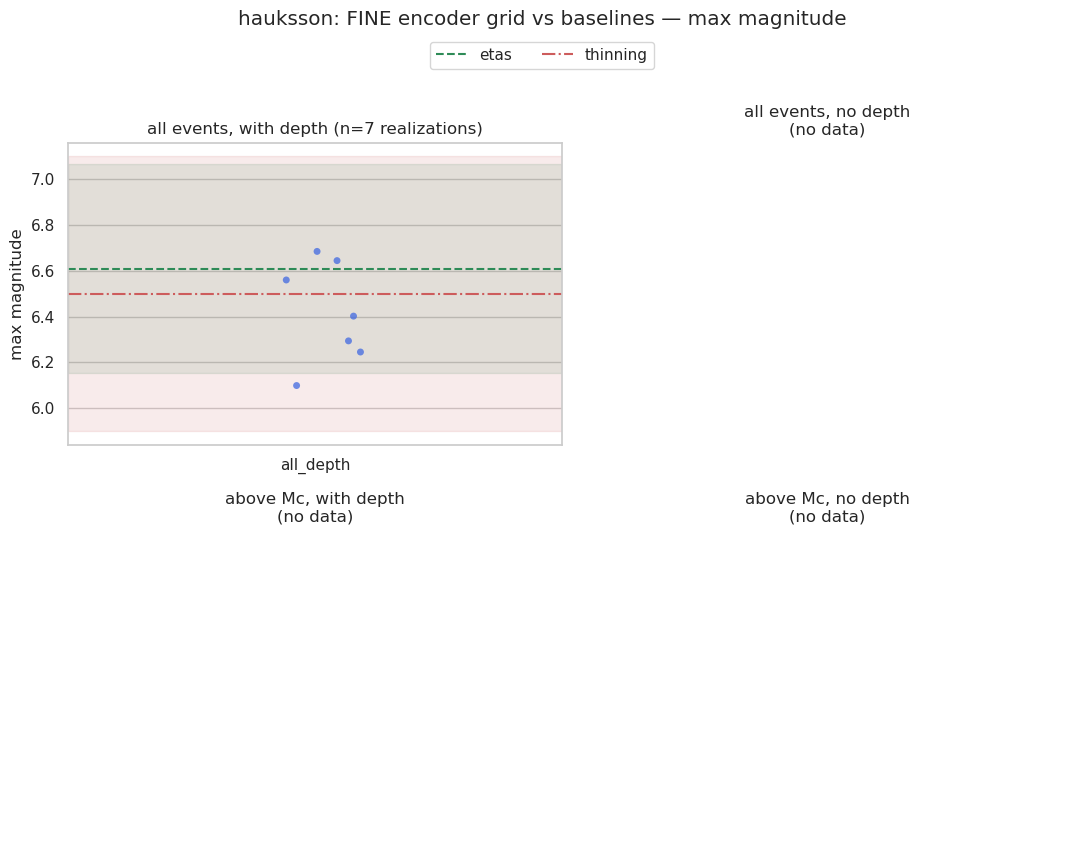

In [5]:
def baseline_band(metrics_df: pd.DataFrame, method: str) -> tuple[float, float] | None:
    sub = metrics_df[(metrics_df["method"] == method) & metrics_df["variant_id"].isna()]
    if sub.empty or METRIC not in sub.columns:
        return None
    vals = sub[METRIC].dropna()
    if vals.empty:
        return None
    return float(vals.mean()), float(vals.std(ddof=1)) if len(vals) > 1 else 0.0


fine = metrics[metrics["method"] == "FINE"].copy()
if fine.empty:
    display(Markdown("_No completed FINE realizations yet for this catalog._"))
else:
    fine["depth_label"] = fine["use_depth_as_feature"].map({True: "with depth", False: "no depth"})
    fine["encoder_label"] = fine["encoder_filter"].map(
        {"all_events": "all events", "above_mc": "above Mc"}
    )

    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
    facet_order = [
        ("all events", "with depth"),
        ("all events", "no depth"),
        ("above Mc", "with depth"),
        ("above Mc", "no depth"),
    ]
    for ax, (enc_lab, depth_lab) in zip(axes.ravel(), facet_order):
        sub = fine[(fine["encoder_label"] == enc_lab) & (fine["depth_label"] == depth_lab)]
        if sub.empty:
            ax.set_title(f"{enc_lab}, {depth_lab}\n(no data)")
            ax.axis("off")
            continue
        sns.stripplot(
            data=sub,
            x="variant_id",
            y=METRIC,
            hue="variant_id",
            dodge=False,
            ax=ax,
            palette=[METHOD_COLORS["FINE"]],
            legend=False,
            alpha=0.75,
            size=5,
        )
        for method, ls in [("etas", "--"), ("thinning", "-.")]:
            band = baseline_band(metrics, method)
            if band is None:
                continue
            mean, std = band
            ax.axhline(mean, color=METHOD_COLORS[method], ls=ls, lw=1.5, label=method)
            if std > 0:
                ax.axhspan(mean - std, mean + std, color=METHOD_COLORS[method], alpha=0.12)
        ax.set_title(f"{enc_lab}, {depth_lab} (n={len(sub)} realizations)")
        ax.set_xlabel("")
        ax.set_ylabel(METRIC_LABELS.get(METRIC, METRIC))
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{CATALOG_ID}: FINE encoder grid vs baselines — {METRIC_LABELS.get(METRIC, METRIC)}", y=1.05)
    fig.tight_layout()
    show_fig(fig)


## Depth pairs — with vs without depth

Side-by-side boxplots for the two encoder-filter settings, comparing depth on/off at matched seeds.

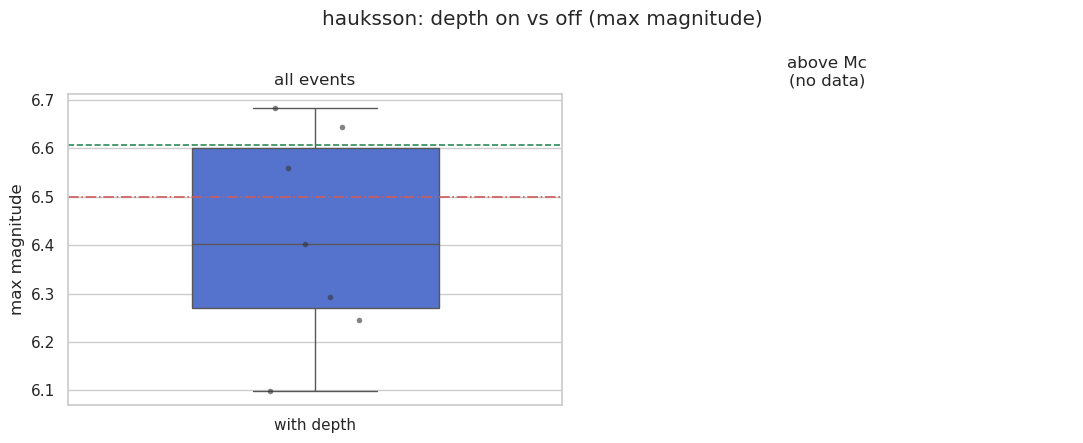

In [6]:
pairs = [
    ("all_depth", "all_nodepth", "all events"),
    ("mc_depth", "mc_nodepth", "above Mc"),
]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (with_id, without_id, title) in zip(axes, pairs):
    sub = fine[fine["variant_id"].isin([with_id, without_id])].copy()
    if sub.empty:
        ax.set_title(f"{title}\n(no data)")
        ax.axis("off")
        continue
    sub["depth"] = sub["variant_id"].map({with_id: "with depth", without_id: "no depth"})
    # paired lines when same seed exists in both variants
    for seed, grp in sub.groupby("seed"):
        if grp["depth"].nunique() == 2:
            ordered = grp.sort_values("depth")
            ax.plot(
                [0, 1],
                ordered[METRIC].to_numpy(),
                color="0.7",
                lw=0.8,
                zorder=1,
            )
    sns.boxplot(data=sub, x="depth", y=METRIC, ax=ax, color=METHOD_COLORS["FINE"], width=0.5)
    sns.stripplot(data=sub, x="depth", y=METRIC, ax=ax, color="0.2", alpha=0.6, size=4)
    for method, ls in [("etas", "--"), ("thinning", "-.")]:
        band = baseline_band(metrics, method)
        if band:
            ax.axhline(band[0], color=METHOD_COLORS[method], ls=ls, lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS.get(METRIC, METRIC))
fig.suptitle(f"{CATALOG_ID}: depth on vs off ({METRIC_LABELS.get(METRIC, METRIC)})")
fig.tight_layout()
show_fig(fig)


## Method ladder — all series on one axis

Baselines plus every FINE variant that has at least one completed seed.

/tmp/ipykernel_1854942/3902468215.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1854942/3902468215.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


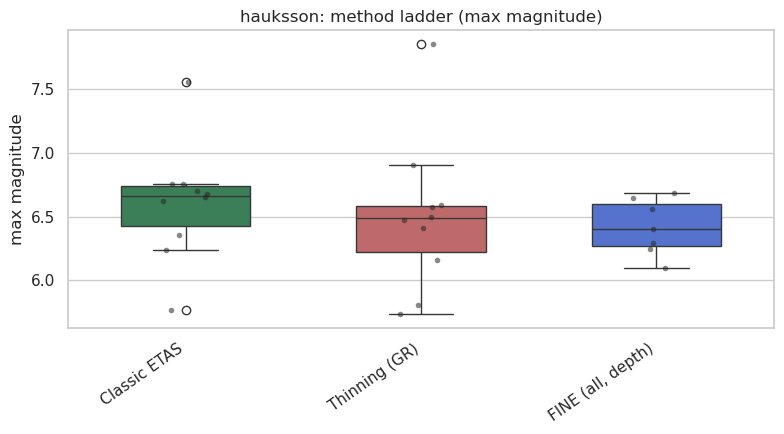

In [7]:
ladder = metrics.copy()
ladder = ladder[ladder[METRIC].notna()]
if ladder.empty:
    display(Markdown("_No metrics to plot._"))
else:
    order = ["Classic ETAS", "Thinning (GR)"]
    order += [
        bmc.variant_grid_label(pd.Series({"variant_id": v["id"], **v}))
        for v in bmc.MAGNET_VARIANTS
        if v["id"] in set(ladder["variant_id"].dropna())
    ]
    ladder["series_label"] = ladder.apply(
        lambda r: r["method_label"] if pd.isna(r["variant_id"]) else bmc.variant_grid_label(r),
        axis=1,
    )
    ladder["series_label"] = pd.Categorical(ladder["series_label"], categories=order, ordered=True)
    ladder = ladder.sort_values("series_label")

    fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(order)), 4.5))
    palette = {
        label: METHOD_COLORS["etas"]
        if "ETAS" in label
        else METHOD_COLORS["thinning"]
        if "Thinning" in label and "FINE" not in label
        else METHOD_COLORS["FINE"]
        for label in order
    }
    sns.boxplot(
        data=ladder,
        x="series_label",
        y=METRIC,
        order=order,
        palette=palette,
        ax=ax,
        width=0.55,
    )
    sns.stripplot(
        data=ladder,
        x="series_label",
        y=METRIC,
        order=order,
        color="0.15",
        alpha=0.55,
        size=4,
        ax=ax,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS.get(METRIC, METRIC))
    ax.set_title(f"{CATALOG_ID}: method ladder ({METRIC_LABELS.get(METRIC, METRIC)})")
    fig.tight_layout()
    show_fig(fig)


## Cross-catalog heatmap (FINE variants)

Mean metric per catalog × variant — useful once multiple catalogs have FINE seeds.

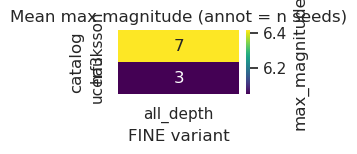

In [8]:
catalogs = bmc.discover_catalog_ids(MATRIX_RUN_ROOT)
heatmap_rows = []
for cat in catalogs:
    m = bmc.load_metrics_long(MATRIX_RUN_ROOT, catalog_id=cat, variant_ids=VARIANT_IDS)
    m = m[m["method"] == "FINE"]
    if m.empty:
        continue
    agg = m.groupby("variant_id", as_index=False).agg(
        n_seeds=("seed", "count"),
        metric_mean=(METRIC, "mean"),
    )
    agg["catalog_id"] = cat
    heatmap_rows.append(agg)

if not heatmap_rows:
    display(Markdown("_No FINE data for heatmap yet._"))
else:
    heat = pd.concat(heatmap_rows, ignore_index=True)
    mat = heat.pivot(index="catalog_id", columns="variant_id", values="metric_mean")
    counts = heat.pivot(index="catalog_id", columns="variant_id", values="n_seeds")
    variant_order = [v["id"] for v in bmc.MAGNET_VARIANTS if v["id"] in mat.columns]
    mat = mat.reindex(columns=variant_order)
    counts = counts.reindex(columns=variant_order)

    fig, ax = plt.subplots(figsize=(1.2 + 1.5 * len(variant_order), 0.6 + 0.55 * len(mat)))
    sns.heatmap(mat, annot=counts.fillna(0).astype(int), fmt="d", cmap="viridis", ax=ax, cbar_kws={"label": METRIC})
    ax.set_title(f"Mean {METRIC_LABELS.get(METRIC, METRIC)} (annot = n seeds)")
    ax.set_xlabel("FINE variant")
    ax.set_ylabel("catalog")
    fig.tight_layout()
    show_fig(fig)
